# Учимся работе с данными - от загрузки до моделирования

In [37]:
#YOUR CODE HERE
#1.Скачайте датасет по ссылке: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data
import kagglehub
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

df = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')
df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [31]:
#2.базовые статистики датасета
print("Размер датасета:", df.shape)
print("\nзначения целевой переменной:")
print(df['diagnosis'].unique())
#print("\nПервые 5 строк:")
#print(df.head())
#print("\nИнформация о данных:")
#print(df.info())
#print("\nСтатистическое описание:")
#print(df.describe())
print("\nПроверка на пропуски:")
print(df.isnull().sum())



Размер датасета: (569, 33)

Проверка на пропуски:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst      


Распределение целевой переменной:
Распределение:
diagnosis
B    357
M    212
Name: count, dtype: int64


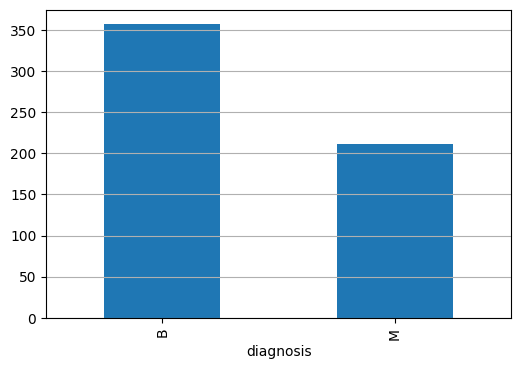

In [40]:

print(f"Распределение целевой переменной:\n{df['diagnosis'].value_counts()}")
df['diagnosis'].value_counts().plot.bar(figsize=(6, 4))
plt.grid(axis='y')
plt.show()

In [28]:
#2.1. средние, медианы etc...
df_clean = df.drop('id', axis=1, errors='ignore')
df_clean['diagnosis_binary'] = df['diagnosis'].map({'B': 0, 'M': 1})
df_clean = df.drop('diagnosis', axis=1, errors='ignore')
df_clean = df.drop('Unnamed', axis=1, errors='ignore')
print(df_clean.head(5))

'''
print("🔄 СРАВНЕНИЕ СРЕДНИХ И МЕДИАН:")
comparison = pd.DataFrame({
    'Mean': df_clean.mean(),
    'Median': df_clean.median(),
    'Difference': df_clean.mean() - df_clean.median(),
    'Skewness': df_clean.skew()
})
#print(comparison)
'''

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

'\nprint("🔄 СРАВНЕНИЕ СРЕДНИХ И МЕДИАН:")\ncomparison = pd.DataFrame({\n    \'Mean\': df_clean.mean(),\n    \'Median\': df_clean.median(),\n    \'Difference\': df_clean.mean() - df_clean.median(),\n    \'Skewness\': df_clean.skew()\n})\n#print(comparison)\n'